In [8]:
# pandas → handle data tables
# numpy → handle numbers
# matplotlib → make graphs
# sklearn → has ready-made machine learning models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [9]:
# Example: Predict if a student passes (1) or fails (0) based on study hours.
# More hours studied → higher chance of passing.

data = {
    'StudyHours': [1,2,3,4,5,6,7,8,9,10],
    'Pass': [0,0,0,0,1,1,1,1,1,1]  # 0 = Fail, 1 = Pass
}
df = pd.DataFrame(data)

df.head()

,StudyHours,Pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1


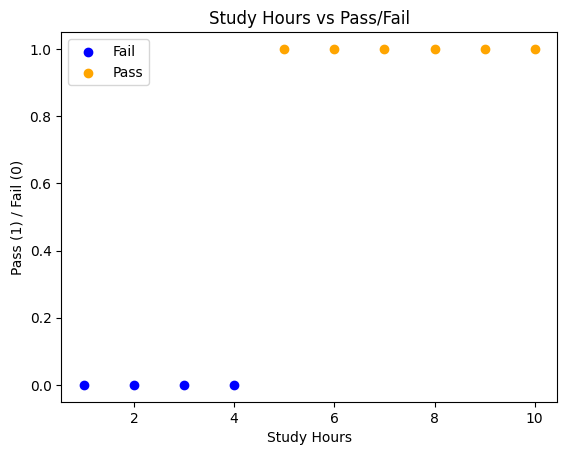

In [10]:
# Scatter plot: dots show study hours vs pass/fail.
# Blue = fail, orange = pass.

# Fail = 0, Pass = 1
fail = df[df['Pass'] == 0]
passed = df[df['Pass'] == 1]

plt.scatter(fail['StudyHours'], fail['Pass'], color='blue', label='Fail')
plt.scatter(passed['StudyHours'], passed['Pass'], color='orange', label='Pass')

plt.xlabel("Study Hours")
plt.ylabel("Pass (1) / Fail (0)")
plt.title("Study Hours vs Pass/Fail")
plt.legend()
plt.show()

In [11]:
# X = input (study hours)
# y = output (pass/fail)
# Model learns probability of passing based on hours.

X = df[['StudyHours']]
y = df['Pass']

model = LogisticRegression()
model.fit(X, y)

print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [[1.18194943]]
Model Intercept: [-5.31167434]


In [12]:
# Predict probability of passing for 4 hours of study.
# Output is probability between 0 and 1.

probability = model.predict_proba([[4]])
print("Probability of passing with 4 hours study:", probability[0][1])

# Predict actual class (0 or 1)
prediction = model.predict([[4]])
print("Predicted outcome:", prediction[0])

Probability of passing with 4 hours study: 0.3580410713791543
Predicted outcome: 0


C:\Users\singh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\singh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


C:\Users\singh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


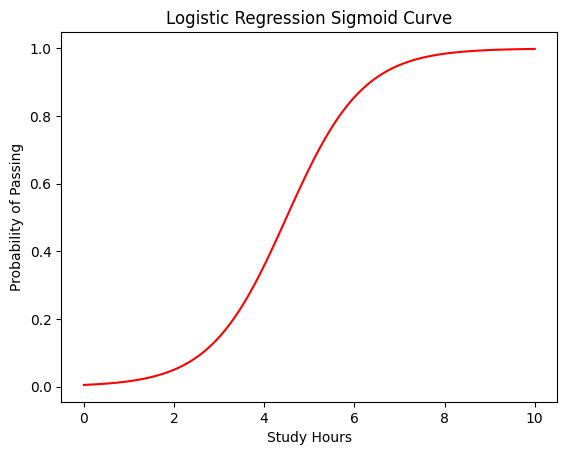

In [13]:
# Logistic regression produces an S-shaped curve (sigmoid).
# Shows how probability changes with study hours.

X_range = np.linspace(0, 10, 100).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]

plt.plot(X_range, y_prob, color='red')
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Sigmoid Curve")
plt.show()